In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (6)\Simple RFM Customer Segmentation - K Means Practice.csv")
print(df.head())

   customer_id  monetary_purchase_amt  frequency_purchase  recency_of_purchase
0            1               3.097321           18.795885            15.108402
1            2               8.759256           21.893389            13.801586
2            3              16.634326            4.270323            23.046506
3            4              10.934102           22.335917            15.445987
4            5              13.832831           22.255416            16.896821


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


   Cluster
0        1
1        1
2        2
3        1
4        1


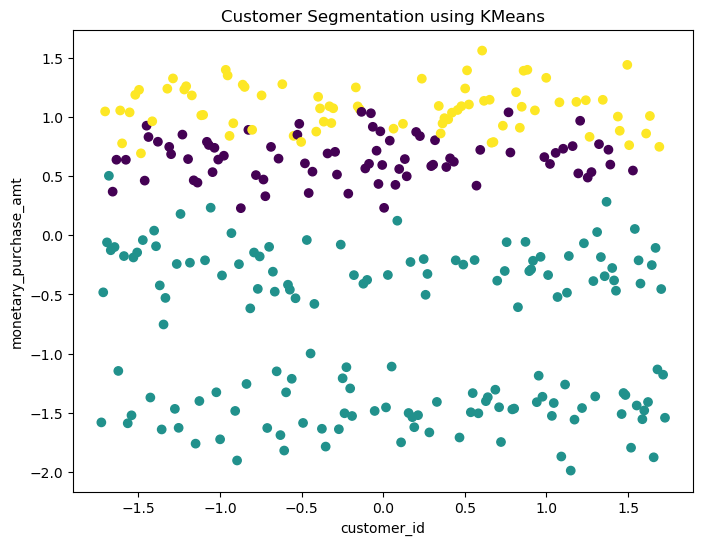

Clusters : 2
Inertia : 675.9149350804361
Clusters : 3
Inertia : 387.04891364364937
Clusters : 4
Inertia : 331.0570206592121
Clusters : 5
Inertia : 200.61843333976674


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (6)\Simple RFM Customer Segmentation - K Means Practice.csv")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
data = df[num_cols]
data = data.fillna(data.median())
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
clusters = kmeans.fit_predict(scaled_data)
df['Cluster'] = clusters
print(df[['Cluster']].head())
plt.figure(figsize=(8,6))
plt.scatter(
    scaled_data[:, 0],
    scaled_data[:, 1],
    c=clusters
)
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("Customer Segmentation using KMeans")
plt.show()
for k in [2, 3, 4, 5]:
    
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(scaled_data)
    print("Clusters :", k)
    print("Inertia :", model.inertia_)